In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("global_ev_adoption_behavior_2026.csv")

In [3]:
df

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,27,26296.0,Bachelor,Urban,37.4,211.4,Sedan,0.0,314.8,10.0,...,9.9,6.6,8.9,5.1,7.8,9.3,1,High,162.5,37.5
49996,39,35476.0,Master,Suburban,30.5,158.3,Sedan,2.8,278.5,7.5,...,8.7,6.0,9.4,3.8,2.0,8.8,0,High,129.6,11.9
49997,30,20862.0,Master,Suburban,37.5,295.2,Sedan,0.0,358.4,7.7,...,7.3,6.6,4.5,5.2,1.3,5.9,0,High,218.3,52.8
49998,68,14694.0,Bachelor,Rural,40.3,256.5,Sedan,6.0,306.1,2.7,...,8.3,3.8,6.6,4.7,5.4,9.3,0,High,216.0,50.3


### Data Inspection

In [5]:
print(f"Total rows in the dataset: {df.shape[0]}")
print(f"Total columns in the dataset: {df.shape[1]}")

Total rows in the dataset: 50000
Total columns in the dataset: 23


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

In [7]:
(
    df.isnull().sum().sort_values(ascending=False)
    .reset_index().
    rename(columns={'index':"Missing Value", 0: 'count'})
)

,Missing Value,count
0,education_level,500
1,ev_knowledge_score,500
2,charging_station_accessibility,500
3,age,0
4,environmental_awareness_score,0
5,monthly_energy_consumption_kwh,0
6,ev_adoption_likelihood,0
7,previous_ev_experience,0
8,battery_replacement_concern,0
9,range_anxiety_score,0


In [8]:
df["education_level"].value_counts(normalize=True)

education_level
Bachelor       0.451515
High School    0.250525
Master         0.247354
PhD            0.050606
Name: proportion, dtype: float64

In [9]:
df['education_level'] = df['education_level'].fillna(df['education_level'].mode())

In [10]:
df['ev_knowledge_score'] = df['ev_knowledge_score'].fillna(df['ev_knowledge_score'].median())
df['charging_station_accessibility'] = (df['charging_station_accessibility']
                                         .fillna(df['charging_station_accessibility'].median()))

In [11]:
pd.set_option('display.max_columns', None)

In [12]:
df.duplicated().sum()

0

In [13]:
target = 'ev_adoption_likelihood'

### Exploratory Data Analysis (EDA) & Staitistical Analysis

In [15]:
df.describe().round(3)

,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,monthly_energy_consumption_kwh,monthly_charging_cost
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,44.996,44311.869,35.169,228.727,6.013,295.170,5.893,7.132,0.650,0.215,6.832,5.980,6.722,5.288,4.998,6.758,0.198,186.740,40.235
std,14.111,26109.171,14.736,101.147,2.947,130.179,2.141,4.802,0.477,0.078,1.920,1.955,1.991,2.060,1.955,1.936,0.399,88.245,24.940
min,21.000,5104.000,5.000,25.000,0.000,-99.700,1.000,0.500,0.000,0.080,2.000,1.000,2.000,2.000,1.000,1.000,0.000,15.600,1.400
25%,33.000,25617.750,25.000,157.700,3.900,205.200,4.400,3.000,0.000,0.150,5.400,4.600,5.200,3.700,3.600,5.400,0.000,124.500,21.600
50%,45.000,37891.000,35.100,224.100,6.000,294.800,5.900,6.900,1.000,0.220,7.000,6.000,6.700,5.000,5.000,7.000,0.000,179.300,35.200
75%,57.000,56051.250,45.200,294.500,8.000,383.000,7.400,10.700,1.000,0.280,8.400,7.300,8.500,6.800,6.300,8.300,0.000,241.500,54.100
max,69.000,250000.000,97.900,732.300,20.000,862.000,10.000,28.500,1.000,0.350,10.000,10.000,10.000,10.000,10.000,10.000,1.000,645.900,199.600


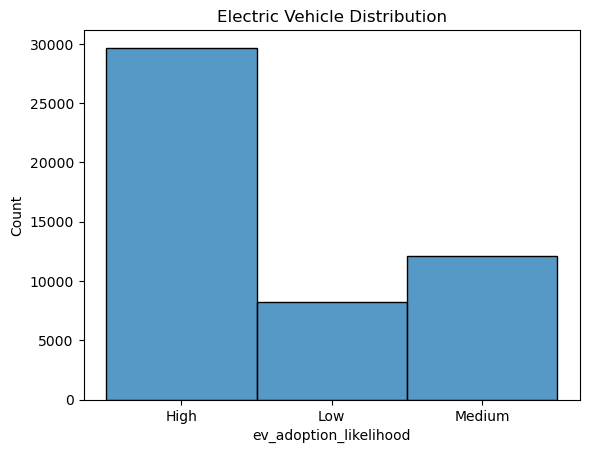

In [16]:
sns.histplot(df['ev_adoption_likelihood'])
plt.title("Electric Vehicle Distribution");

In [17]:
cat_col = df.select_dtypes('O').columns
num_col = df.select_dtypes('number').columns.tolist()
print(f"Categorical columns: {cat_col}")
print(f"Numerical Columns: {num_col}")

Categorical columns: Index(['education_level', 'city_type', 'current_vehicle_type',
       'ev_adoption_likelihood'],
      dtype='object')
Numerical Columns: ['age', 'annual_income', 'daily_commute_km', 'weekly_travel_distance_km', 'vehicle_age_years', 'fuel_expense_per_month', 'charging_station_accessibility', 'nearest_charging_station_km', 'home_charging_available', 'electricity_cost_per_kwh', 'environmental_awareness_score', 'government_incentive_awareness', 'technology_affinity_score', 'range_anxiety_score', 'battery_replacement_concern', 'ev_knowledge_score', 'previous_ev_experience', 'monthly_energy_consumption_kwh', 'monthly_charging_cost']


In [18]:
bin = [18, 25, 35, 45, 55, 65, 100]
label = ['18-24','25-34','35-44','45-54','55-64','65+']
pd.cut(df['age'], bins =bin, labels=label)

0        55-64
1        45-54
2        45-54
3        18-24
4        45-54
         ...  
49995    25-34
49996    35-44
49997    25-34
49998      65+
49999    45-54
Name: age, Length: 50000, dtype: category
Categories (6, object): ['18-24' < '25-34' < '35-44' < '45-54' < '55-64' < '65+']

In [19]:
ct = (
    pd.crosstab(
        pd.cut(df['age'], bins =bin, labels=label),
        df['ev_adoption_likelihood'],
        normalize='index'
    )*100
)
ct

ev_adoption_likelihood,High,Low,Medium
age,,,
18-24,59.018619,16.563227,24.418154
25-34,59.835660,15.879616,24.284724
35-44,58.837963,16.979095,24.182942
45-54,59.147579,16.623176,24.229245
55-64,59.476162,16.548950,23.974887
65+,59.930227,16.371792,23.697982


In [20]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(ct)
print(f"P-value: {p}")

P-value: 0.9999999995737973


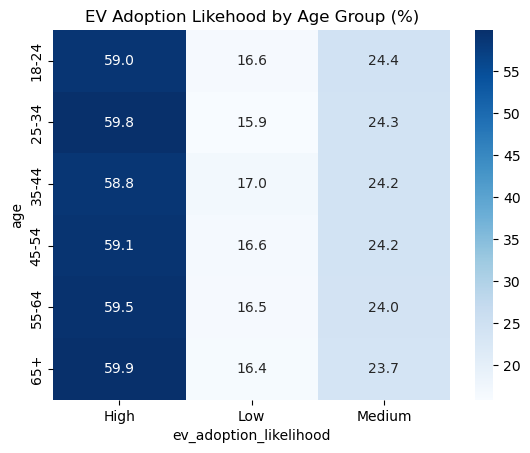

In [21]:
sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues')
plt.title('EV Adoption Likehood by Age Group (%)');

In [22]:
ct_inc = pd.crosstab(
    df['annual_income'],
    df['ev_adoption_likelihood'],
    normalize='index'
)
ct_inc

ev_adoption_likelihood,High,Low,Medium
annual_income,,,
5104.0,0.0,0.0,1.0
5107.0,0.0,0.0,1.0
5274.0,1.0,0.0,0.0
5344.0,0.0,0.0,1.0
5357.0,0.0,1.0,0.0
...,...,...,...
233927.0,1.0,0.0,0.0
237175.0,1.0,0.0,0.0
243962.0,1.0,0.0,0.0


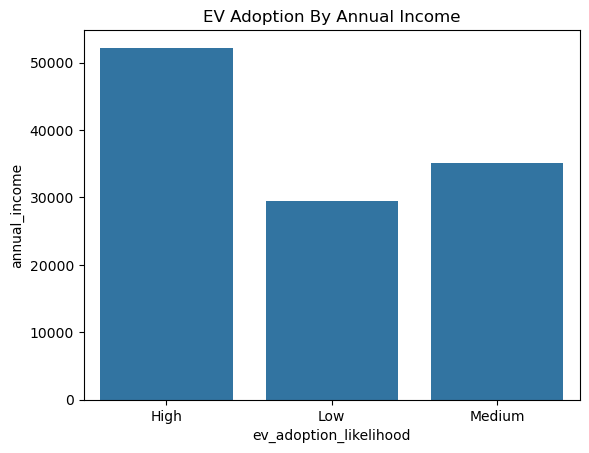

In [23]:
sns.barplot(df, x='ev_adoption_likelihood',y='annual_income',errorbar=None)
plt.title("EV Adoption By Annual Income");

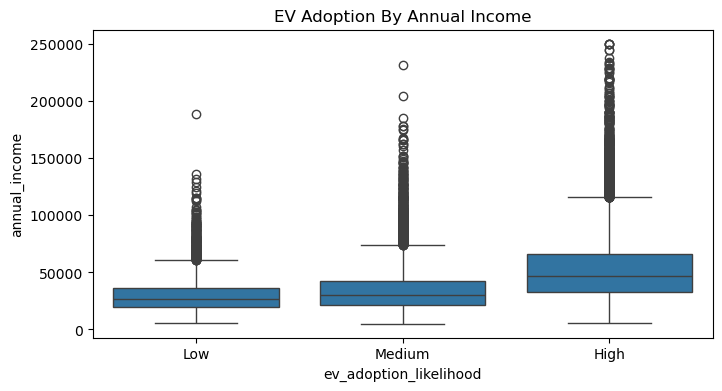

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(df, x='ev_adoption_likelihood', y='annual_income',order=['Low', 'Medium','High'])
plt.title("EV Adoption By Annual Income");

In [25]:
import scipy.stats as stat
low_inc = df[df['ev_adoption_likelihood']=='Low']['annual_income']
mid_inc = df[df['ev_adoption_likelihood']=='Medium']['annual_income']
high_inc = df[df['ev_adoption_likelihood']=='Low']['annual_income']

f_stat, p_val = stat.f_oneway(low_inc, mid_inc, high_inc)
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_val:.7f}")
if p_val < 0.05:
    print(f"Annoual Income statistically have influence on Electric Vehicle Adoption Likelyhood")
elif p_val > 0.05:
    print(f"Annoual Income does not statistically have influence on Electric Vehicle Adoption Likelyhood")

F-statistic: 391.9615683539211
P-value: 0.0000000
Annoual Income statistically have influence on Electric Vehicle Adoption Likelyhood


In [26]:
ct = pd.crosstab(
    df['education_level'],
    df['ev_adoption_likelihood'],
    normalize='index'
)
ct

ev_adoption_likelihood,High,Low,Medium
education_level,,,
Bachelor,0.596152,0.164116,0.239732
High School,0.589791,0.165632,0.244577
Master,0.593352,0.166367,0.240281
PhD,0.591218,0.166068,0.242715


In [27]:
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi2 Statistic: {chi2}")
print(f"P-value: {p}")

Chi2 Statistic: 0.00011946006745890917
P-value: 0.9999999999999645


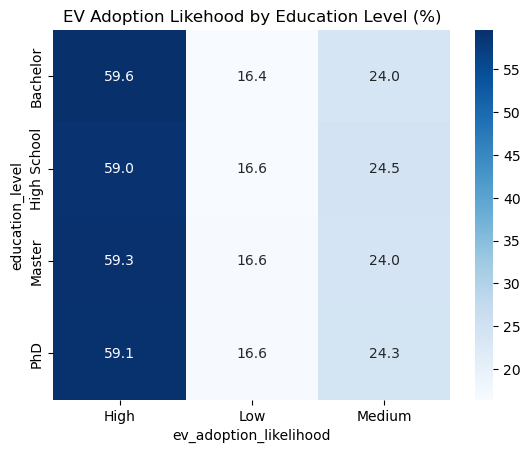

In [28]:
sns.heatmap(ct*100, annot=True, fmt='.1f', cmap='Blues')
plt.title('EV Adoption Likehood by Education Level (%)');

In [29]:
ct*100

ev_adoption_likelihood,High,Low,Medium
education_level,,,
Bachelor,59.615213,16.411633,23.973154
High School,58.979115,16.563180,24.457705
Master,59.335185,16.636720,24.028095
PhD,59.121756,16.606786,24.271457


In [30]:
for col in df[cat_col]:
    ct = pd.crosstab(
    df[col],
    df['ev_adoption_likelihood'],
    normalize='index'
)*100
    print(f"\n===== Crosstab: {col} vs Electric Vehicle Adoption Likelyhood =====")
    print(ct.round(2))
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"Chi-Square Test for {col}: χ²={chi2:.2f}, p-value={p:.4f}")
    if p > 0.05:
        print(f"There's no significant different between {col}({p:.4f}) and Electric Vehicle Adoption Likelyhood")
    elif p < 0.05:
        print(f"There is significant different between {col}({p:.4f}) and Electric Vehicle Adoption Likelyhood")
    else:
        print("")


===== Crosstab: education_level vs Electric Vehicle Adoption Likelyhood =====
ev_adoption_likelihood   High    Low  Medium
education_level                             
Bachelor                59.62  16.41   23.97
High School             58.98  16.56   24.46
Master                  59.34  16.64   24.03
PhD                     59.12  16.61   24.27
Chi-Square Test for education_level: χ²=0.01, p-value=1.0000
There's no significant different between education_level(1.0000) and Electric Vehicle Adoption Likelyhood

===== Crosstab: city_type vs Electric Vehicle Adoption Likelyhood =====
ev_adoption_likelihood   High    Low  Medium
city_type                                   
Rural                   54.81  19.70   25.49
Suburban                54.54  19.70   25.76
Urban                   65.02  12.65   22.34
Chi-Square Test for city_type: χ²=3.43, p-value=0.4883
There's no significant different between city_type(0.4883) and Electric Vehicle Adoption Likelyhood

===== Crosstab: current_vehicl

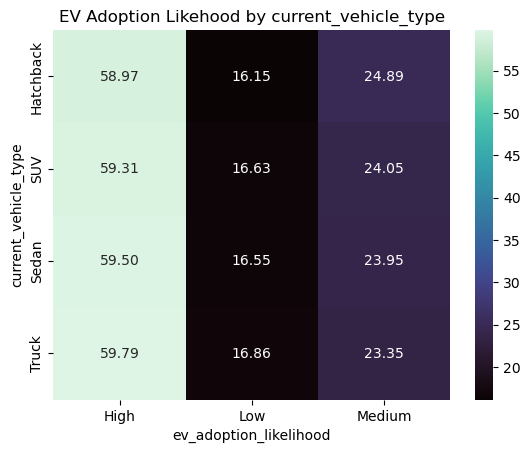

In [31]:
sns.heatmap(
            pd.crosstab(
        df['current_vehicle_type'],
        df['ev_adoption_likelihood'],
        normalize='index'
    )*100,
            annot=True, fmt='.2f', cmap='mako')
plt.title("EV Adoption Likehood by current_vehicle_type");

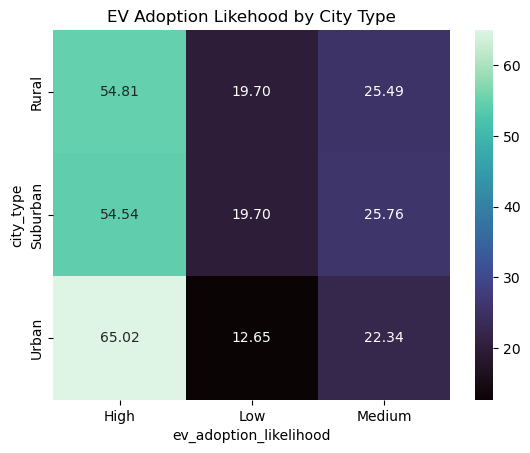

In [32]:
sns.heatmap(
            pd.crosstab(
        df['city_type'],
        df['ev_adoption_likelihood'],
        normalize='index'
    )*100,
            annot=True, fmt='.2f', cmap='mako')
plt.title("EV Adoption Likehood by City Type");

In [33]:
low_tr = df[df['ev_adoption_likelihood']=='Low']['weekly_travel_distance_km']
mid_tr = df[df['ev_adoption_likelihood']=='Medium']['weekly_travel_distance_km']
high_tr = df[df['ev_adoption_likelihood']=='High']['weekly_travel_distance_km']

f_stat, p_val = stat.f_oneway(low_tr, mid_tr, high_tr)
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_val:.7f}")
if p_val < 0.05:
    print(f"Weekly Travel Distance (km) statistically have effect on Electric Vehicle Adoption Likelyhood")
elif p_val > 0.05:
    print(f"Weekly Travel Distance (km) does not statistically have effect on Electric Vehicle Adoption Likelyhood")

F-statistic: 0.3074326552482614
P-value: 0.7353338
Weekly Travel Distance (km) does not statistically have effect on Electric Vehicle Adoption Likelyhood


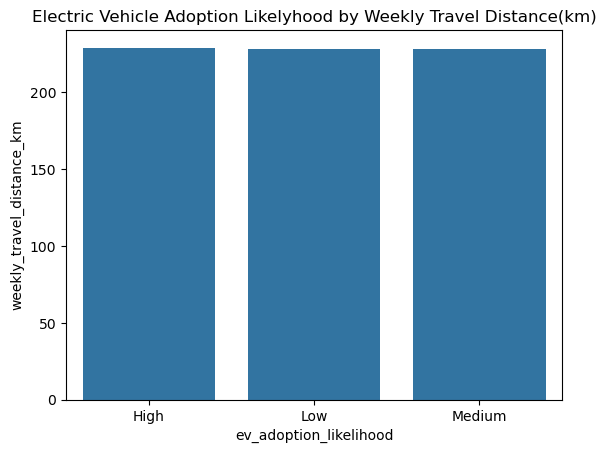

In [34]:
sns.barplot(df, x='ev_adoption_likelihood', y='weekly_travel_distance_km', errorbar=None)
plt.title("Electric Vehicle Adoption Likelyhood by Weekly Travel Distance(km)");

In [35]:
low_tr = df[df['ev_adoption_likelihood']=='Low']['environmental_awareness_score']
mid_tr = df[df['ev_adoption_likelihood']=='Medium']['environmental_awareness_score']
high_tr = df[df['ev_adoption_likelihood']=='High']['environmental_awareness_score']

f_stat, p_val = stat.f_oneway(low_tr, mid_tr, high_tr)
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_val:.7f}")
if p_val < 0.05:
    print(f"Environmental Awareness statistically increase Electric Vehicle Adoption Likelyhood")
elif p_val > 0.05:
    print(f"Environmental Awareness does not statistically increase Electric Vehicle Adoption Likelyhood")

F-statistic: 22733.455309291276
P-value: 0.0000000
Environmental Awareness statistically increase Electric Vehicle Adoption Likelyhood


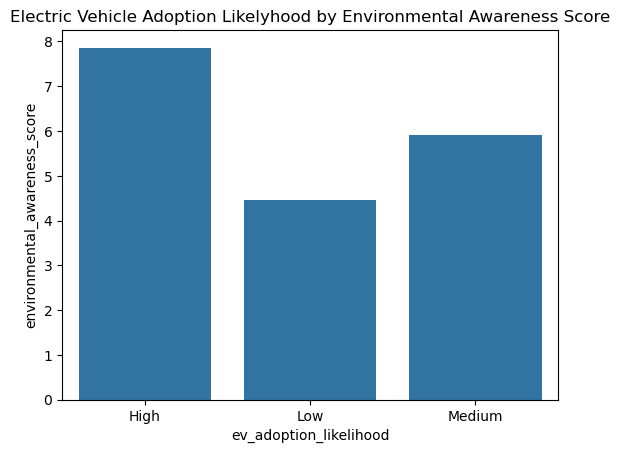

In [36]:
sns.barplot(df, x='ev_adoption_likelihood', y='environmental_awareness_score', errorbar=None)
plt.title("Electric Vehicle Adoption Likelyhood by Environmental Awareness Score");

In [37]:
low_chr = df[df['ev_adoption_likelihood']=='Low']['nearest_charging_station_km']
mid_chr = df[df['ev_adoption_likelihood']=='Medium']['nearest_charging_station_km']
high_chr = df[df['ev_adoption_likelihood']=='High']['nearest_charging_station_km']

f_stat, p_val = stat.f_oneway(low_chr, mid_chr, high_chr)
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_val:.7f}")
if p_val < 0.05:
    print(f"Nearest Charging Station statistically affect Electric Vehicle Adoption Likelyhood")
elif p_val > 0.05:
    print(f"Eearest Charging Station does not statistically affect Electric Vehicle Adoption Likelyhood")

F-statistic: 302.8925321810806
P-value: 0.0000000
Nearest Charging Station statistically affect Electric Vehicle Adoption Likelyhood


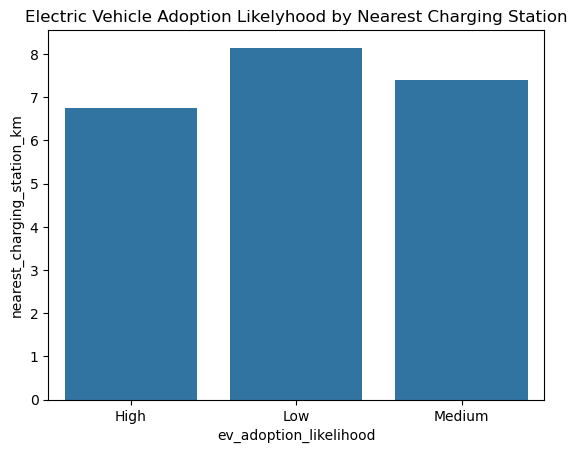

In [38]:
sns.barplot(df, x='ev_adoption_likelihood', y='nearest_charging_station_km', errorbar=None)
plt.title("Electric Vehicle Adoption Likelyhood by Nearest Charging Station");

In [39]:
df.corr(numeric_only=True).round(3)

,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,monthly_energy_consumption_kwh,monthly_charging_cost
age,1.000,-0.004,-0.005,-0.005,-0.002,-0.004,-0.005,-0.001,0.000,-0.000,-0.005,0.002,-0.001,0.001,-0.000,-0.005,-0.000,-0.003,-0.002
annual_income,-0.004,1.000,0.000,-0.000,0.002,-0.000,0.000,-0.004,-0.003,0.005,0.317,0.003,0.449,-0.370,0.002,0.381,-0.006,0.003,0.004
daily_commute_km,-0.005,0.000,1.000,0.945,-0.006,0.952,-0.003,0.001,0.009,0.000,0.005,-0.001,0.005,0.001,-0.004,0.001,0.001,0.885,0.676
weekly_travel_distance_km,-0.005,-0.000,0.945,1.000,-0.003,0.899,-0.001,0.001,0.009,0.002,0.006,-0.001,0.005,-0.001,-0.001,0.001,-0.002,0.936,0.715
vehicle_age_years,-0.002,0.002,-0.006,-0.003,1.000,-0.009,-0.011,0.007,-0.000,0.008,-0.007,-0.000,-0.003,-0.002,-0.007,-0.005,-0.000,-0.003,-0.000
fuel_expense_per_month,-0.004,-0.000,0.952,0.899,-0.009,1.000,-0.004,-0.002,0.008,0.002,0.004,0.002,0.004,0.002,-0.004,0.000,0.003,0.842,0.644
charging_station_accessibility,-0.005,0.000,-0.003,-0.001,-0.011,-0.004,1.000,-0.292,-0.001,-0.005,0.004,-0.004,0.004,-0.001,0.001,0.007,-0.005,-0.000,-0.002
nearest_charging_station_km,-0.001,-0.004,0.001,0.001,0.007,-0.002,-0.292,1.000,-0.001,0.003,-0.003,-0.003,-0.001,0.002,-0.004,-0.004,-0.009,0.001,0.001
home_charging_available,0.000,-0.003,0.009,0.009,-0.000,0.008,-0.001,-0.001,1.000,0.009,-0.006,0.002,-0.004,0.006,-0.000,-0.008,0.012,0.007,0.010
electricity_cost_per_kwh,-0.000,0.005,0.000,0.002,0.008,0.002,-0.005,0.003,0.009,1.000,-0.003,0.006,0.005,-0.002,0.011,0.005,0.004,0.003,0.584


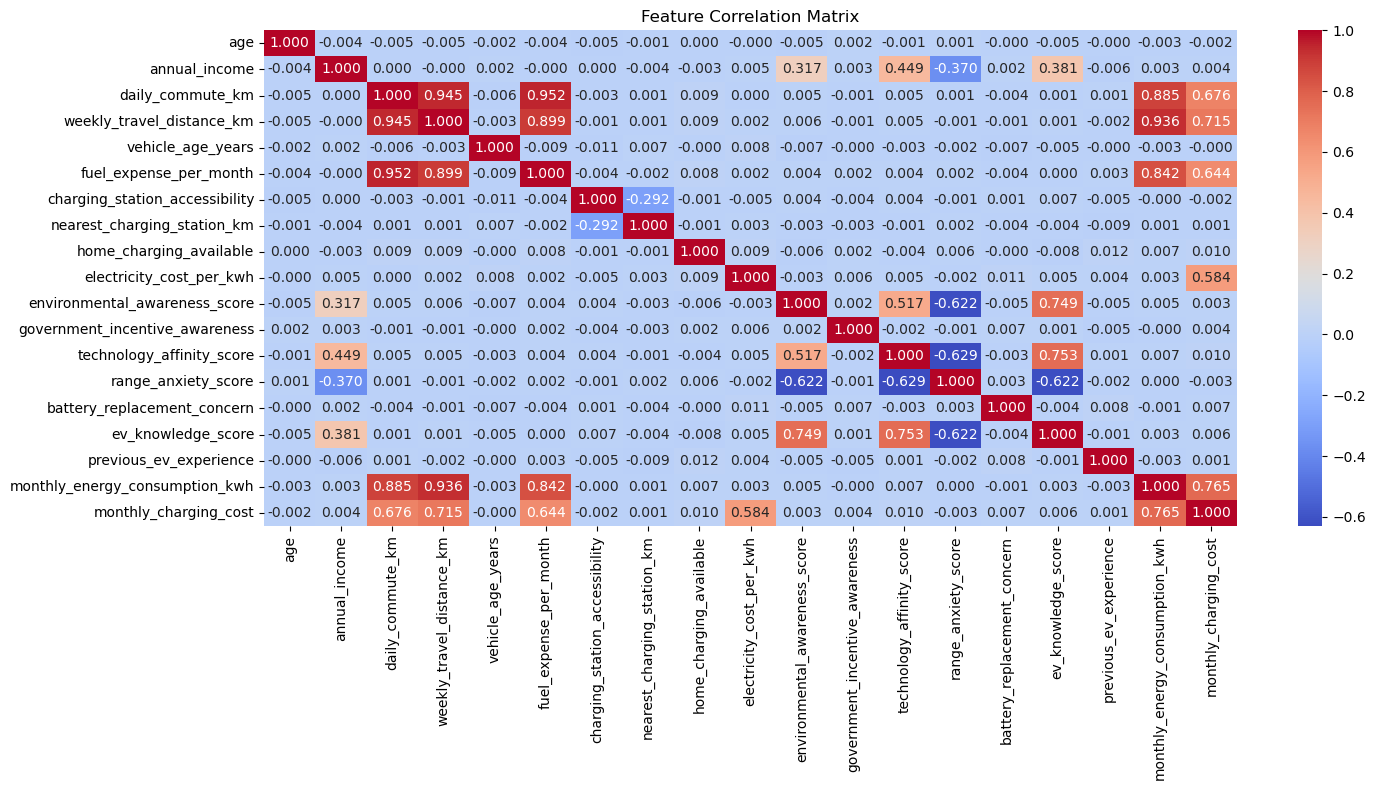

In [40]:
fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(1, 1)

ax = fig.add_subplot(gs[0, 0])
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm',fmt='.3f', ax=ax)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

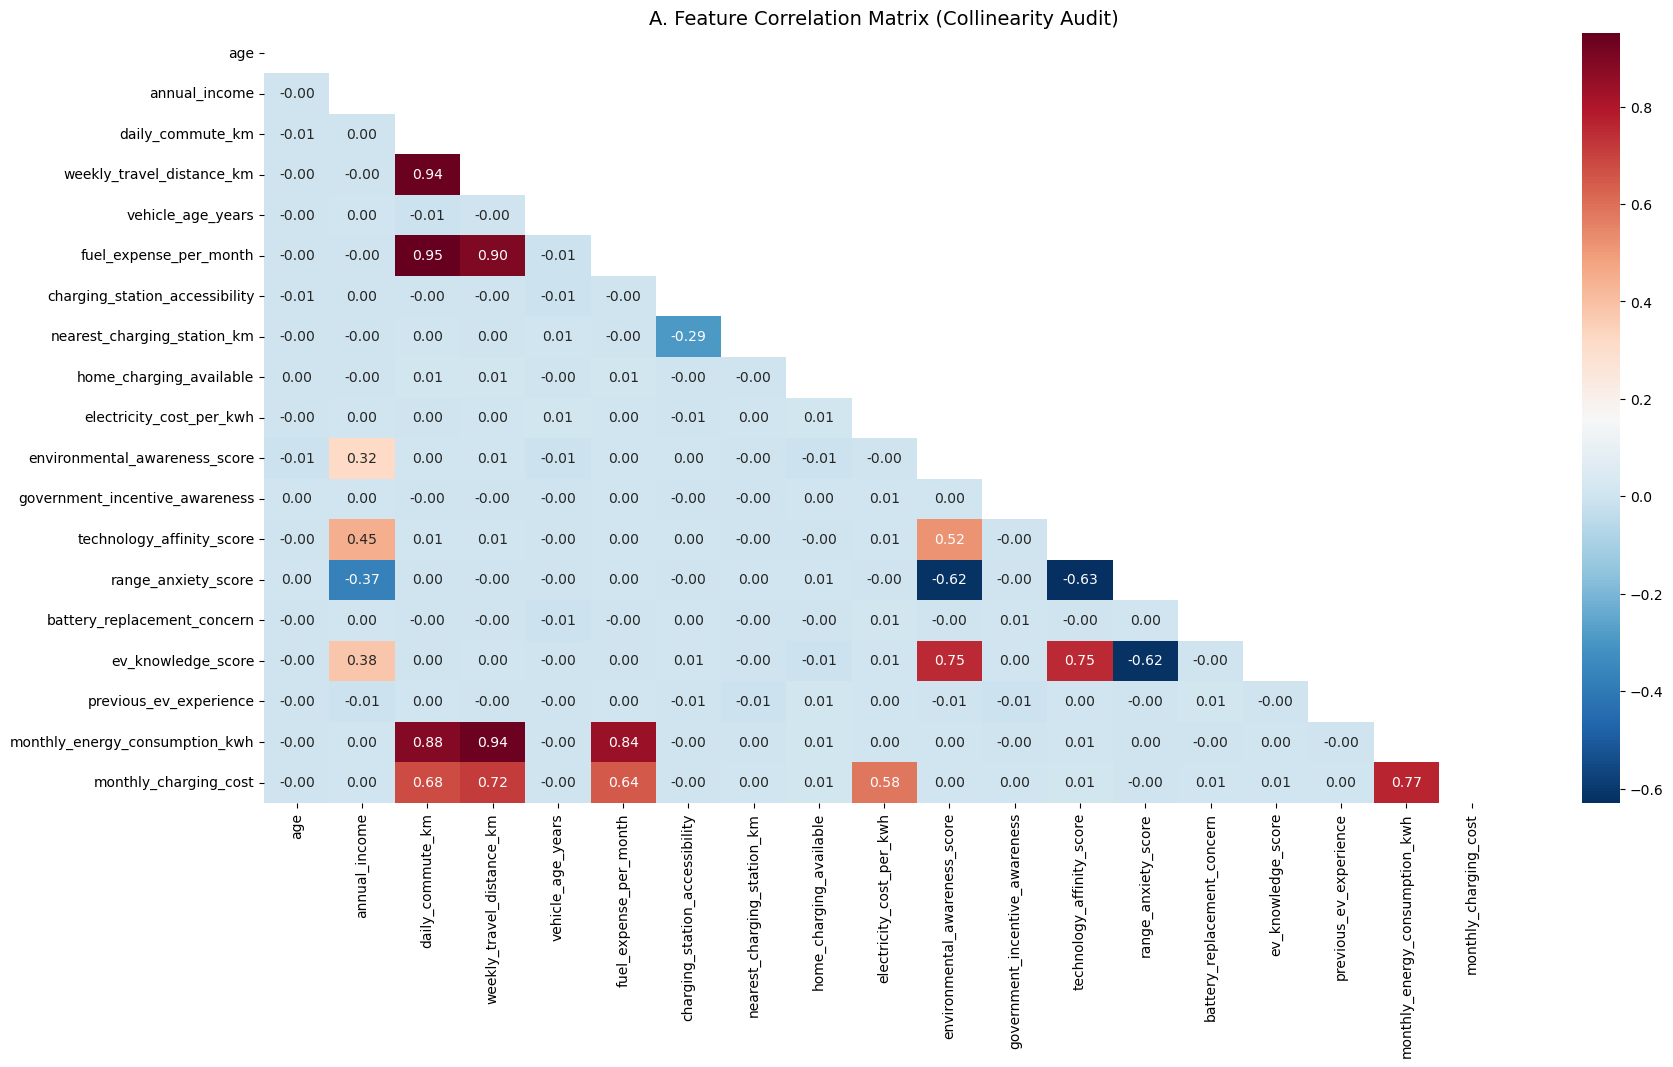

In [41]:
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(1, 1)
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = fig.add_subplot(gs[0,0])
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', ax=ax)
plt.title("A. Feature Correlation Matrix (Collinearity Audit)", fontsize=14);

In [42]:
for col in df[num_col]:
    low_col = df[df['ev_adoption_likelihood']=='Low'][col]
    mid_col = df[df['ev_adoption_likelihood']=='Medium'][col]
    high_col = df[df['ev_adoption_likelihood']=='High'][col]

    f_stat, p_val = stat.f_oneway(low_col, mid_col, high_col)
    print('=='*15,"One way Anova",'=='*15)
    print(f"{col} vs Electric Vehicle Adoption Likelyhood")
    print(f"F-statistic: {f_stat}")
    print(f"P-value: {p_val:.7f}")
    if p_val < 0.05:
        print(f"Interpretation: {col} significantly influence Electric Vehicle Adoption Likelyhood")
    elif p_val > 0.05:
        print(f"Interpretation: {col} does not significantly influence Electric Vehicle Adoption Likelyhood")

============================== One way Anova ==============================
age vs Electric Vehicle Adoption Likelyhood
F-statistic: 0.2791621970161657
P-value: 0.7564184
Interpretation: age does not significantly influence Electric Vehicle Adoption Likelyhood
============================== One way Anova ==============================
annual_income vs Electric Vehicle Adoption Likelyhood
F-statistic: 4019.2491396923424
P-value: 0.0000000
Interpretation: annual_income significantly influence Electric Vehicle Adoption Likelyhood
============================== One way Anova ==============================
daily_commute_km vs Electric Vehicle Adoption Likelyhood
F-statistic: 0.43781053345452015
P-value: 0.6454505
Interpretation: daily_commute_km does not significantly influence Electric Vehicle Adoption Likelyhood
============================== One way Anova ==============================
weekly_travel_distance_km vs Electric Vehicle Adoption Likelyhood
F-statistic: 0.3074326552482614
P-val

In [43]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.miscmodels.ordinal_model import OrderedModel
import statsmodels.api as sm
scaler = StandardScaler()

In [44]:
X = df[num_col].copy()

In [45]:
df[target] = df[target].map({'Low':0, 'Medium':1, 'High':2})

In [46]:
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled_const = sm.add_constant(
    X_scaled.drop(columns=['weekly_travel_distance_km','fuel_expense_per_month','monthly_charging_cost']))
vif_data = pd.Series([variance_inflation_factor(X_scaled_const.values, i)
                     for i in range(X_scaled_const.shape[1])], index=X_scaled_const.columns)
logit_model = OrderedModel(df[target], X_scaled_const.drop(columns='const'),distr='logit').fit(disp=0)
or_summary = np.exp(logit_model.params).to_frame(name='Odds Ratio')
or_summary['95% CI Lower'] = np.exp(logit_model.conf_int()[0])
or_summary['95% CI Upper'] = np.exp(logit_model.conf_int()[1])
or_summary['VIF'] = vif_data
or_summary['P-Value'] = logit_model.pvalues
print(or_summary.round(4))

                                Odds Ratio  95% CI Lower  95% CI Upper  \
age                                 1.0374        1.0168        1.0584   
annual_income                       0.7067        0.6904        0.7235   
daily_commute_km                    0.9123        0.8738        0.9524   
vehicle_age_years                   0.6400        0.6269        0.6533   
charging_station_accessibility      1.0703        1.0479        1.0931   
nearest_charging_station_km         0.9832        0.9629        1.0040   
home_charging_available             1.2661        1.2410        1.2917   
electricity_cost_per_kwh            1.0440        1.0232        1.0652   
environmental_awareness_score       1.4439        1.3979        1.4914   
government_incentive_awareness      1.7943        1.7571        1.8322   
technology_affinity_score           1.5050        1.4551        1.5566   
range_anxiety_score                 0.2470        0.2394        0.2549   
battery_replacement_concern         0.

C:\Users\HELLO\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### FEATURE ENGINEERING

In [49]:
df['annual_icome_brac'] = df['annual_income'].map(
    lambda x: 'Low' if x < 50_000 else 'Medium' if x <= 150_000 else 'High'
)

In [50]:
bin = [18, 25, 35, 45, 55, 65, 100]
label = ['18-24','25-34','35-44','45-54','55-64','65+']
df['age_group'] = pd.cut(df['age'], bins =bin, labels=label)

In [51]:
bin = [0, 5, 15, 30, 50, float('inf')]
label = ['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
df['commute_categories'] = pd.cut(df['daily_commute_km'], bins=bin, labels=label)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   age                             50000 non-null  int64   
 1   annual_income                   50000 non-null  float64 
 2   education_level                 49500 non-null  object  
 3   city_type                       50000 non-null  object  
 4   daily_commute_km                50000 non-null  float64 
 5   weekly_travel_distance_km       50000 non-null  float64 
 6   current_vehicle_type            50000 non-null  object  
 7   vehicle_age_years               50000 non-null  float64 
 8   fuel_expense_per_month          50000 non-null  float64 
 9   charging_station_accessibility  50000 non-null  float64 
 10  nearest_charging_station_km     50000 non-null  float64 
 11  home_charging_available         50000 non-null  int64   
 12  electricity_cost_p

### PREPROCESSING

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [55]:
cat_col = df.select_dtypes(include='object').columns.tolist()
cat_col = cat_col + ['age_group', 'commute_categories']
cat_col

['education_level',
 'city_type',
 'current_vehicle_type',
 'annual_icome_brac',
 'age_group',
 'commute_categories']

In [56]:
num_col = ['age',
         'annual_income',
         'daily_commute_km',
         'weekly_travel_distance_km',
         'vehicle_age_years',
         'fuel_expense_per_month',
         'charging_station_accessibility',
         'nearest_charging_station_km',
         'home_charging_available',
         'electricity_cost_per_kwh',
         'environmental_awareness_score',
         'government_incentive_awareness',
         'technology_affinity_score',
         'range_anxiety_score',
         'battery_replacement_concern',
         'ev_knowledge_score',
         'previous_ev_experience',
         'monthly_energy_consumption_kwh',
         'monthly_charging_cost']

In [231]:
print(f"Categorical columns: {cat_col}")
print(f"Numerical columns: {num_col}")

Categorical columns: ['education_level', 'city_type', 'current_vehicle_type', 'annual_icome_brac', 'age_group', 'commute_categories']
Numerical columns: ['age', 'annual_income', 'daily_commute_km', 'weekly_travel_distance_km', 'vehicle_age_years', 'fuel_expense_per_month', 'charging_station_accessibility', 'nearest_charging_station_km', 'home_charging_available', 'electricity_cost_per_kwh', 'environmental_awareness_score', 'government_incentive_awareness', 'technology_affinity_score', 'range_anxiety_score', 'battery_replacement_concern', 'ev_knowledge_score', 'previous_ev_experience', 'monthly_energy_consumption_kwh', 'monthly_charging_cost']


In [57]:
X = df[cat_col + num_col]
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(
    X,y, test_size= 0.15,
    random_state = 42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size = 0.1765,
    random_state=42,stratify=y_temp
)

In [58]:
num_pipe = Pipeline([
    ('scaler', StandardScaler())
]
)
cat_pipe = Pipeline([
    ('encode', OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop='first'))
])

pipeline = ColumnTransformer([
    ('num', num_pipe, num_col),
    ('cat', cat_pipe, cat_col)
],verbose_feature_names_out=False, remainder='passthrough')

print(f"Numerical pipeline ✅ \n{num_pipe}")
print(f"Categorical pipeline ✅ \n{cat_pipe}")
print(f"Preprocessor ✅ \n{pipeline}")

Numerical pipeline ✅ 
Pipeline(steps=[('scaler', StandardScaler())])
Categorical pipeline ✅ 
Pipeline(steps=[('encode',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])
Preprocessor ✅ 
ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'annual_income', 'daily_commute_km',
                                  'weekly_travel_distance_km',
                                  'vehicle_age_years', 'fuel_expense_per_month',
                                  'charging_station_accessibility',
                                  'nearest_charging_station_km',
                                  'home_charging_available',
                                  'electricity_cost_per_kwh',
                                  'environme...
                                  'ev_knowledge_s

In [59]:
pipeline

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### Feature Selection

In [61]:
from sklearn.feature_selection import mutual_info_classif

In [62]:
X_proc = pipeline.fit_transform(X_train)
feat_names = pipeline.get_feature_names_out()

mi = mutual_info_classif(
    X_proc, y_train, random_state=42
)

mi_series = pd.Series(mi, index=feat_names).sort_values(ascending=False)
mi_series

ev_knowledge_score                0.350152
range_anxiety_score               0.320863
technology_affinity_score         0.312372
environmental_awareness_score     0.305369
annual_income                     0.100810
annual_icome_brac_Low             0.066497
annual_icome_brac_Medium          0.064397
charging_station_accessibility    0.019956
battery_replacement_concern       0.009962
government_incentive_awareness    0.009525
home_charging_available           0.008160
previous_ev_experience            0.007955
city_type_Urban                   0.006713
commute_categories_Very Long      0.006112
current_vehicle_type_Truck        0.006024
age                               0.005946
nearest_charging_station_km       0.005629
age_group_35-44                   0.005023
age_group_25-34                   0.002713
city_type_Suburban                0.002538
education_level_Master            0.001791
commute_categories_Very Short     0.001535
education_level_PhD               0.001317
commute_cat

In [63]:
pipeline.get_feature_names_out()

array(['age', 'annual_income', 'daily_commute_km',
       'weekly_travel_distance_km', 'vehicle_age_years',
       'fuel_expense_per_month', 'charging_station_accessibility',
       'nearest_charging_station_km', 'home_charging_available',
       'electricity_cost_per_kwh', 'environmental_awareness_score',
       'government_incentive_awareness', 'technology_affinity_score',
       'range_anxiety_score', 'battery_replacement_concern',
       'ev_knowledge_score', 'previous_ev_experience',
       'monthly_energy_consumption_kwh', 'monthly_charging_cost',
       'education_level_High School', 'education_level_Master',
       'education_level_PhD', 'education_level_nan', 'city_type_Suburban',
       'city_type_Urban', 'current_vehicle_type_SUV',
       'current_vehicle_type_Sedan', 'current_vehicle_type_Truck',
       'annual_icome_brac_Low', 'annual_icome_brac_Medium',
       'age_group_25-34', 'age_group_35-44', 'age_group_45-54',
       'age_group_55-64', 'age_group_65+', 'commute_cate

### Model Training

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,classification_report,
                             recall_score, precision_score,confusion_matrix, accuracy_score, roc_curve)

In [66]:
baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline score: {baseline:3f}")

Baseline score: 0.593405


In [67]:
models ={
    'Logistic (Baseline)': Pipeline([    
        ('pipe', pipeline),
        ('classifier', LogisticRegression(
            multi_class='multinomial', solver='lbfgs',
            max_iter=1000,
            class_weight = "balanced",
            random_state=42
        ))
    ]),
    'Random forest': Pipeline([
        ('pipe', pipeline),
        ('clf', RandomForestClassifier(
            class_weight='balanced',
            max_depth = 6,
            n_estimators=100, n_jobs=-1,
            random_state=42
        ))
    ]),
    'Gradient Boost': Pipeline([
        ('pipe', pipeline),
        ('clf',  GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        ))
    ]),
    'XGboost': Pipeline([
        ('pipe', pipeline),
        ('clf', XGBClassifier(
            learning_rate = 0.05, eval_metric='mlogloss',
            objective='multi:softprob', num_class=3,
            subsample =0.8, max_depth=6,
            n_estimators=100, n_jobs=-1,
            random_state=42
        ))
    ]),
    'Lightgbm': Pipeline([
        ('pipe', pipeline),
        ('clf', LGBMClassifier(
            n_estimators=100, class_weight='balanced',
            learning_rate=0.05, verbose=-1,
            random_state=42
        ))
    ])
}

result = []

cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)
scoring = {
    "roc_auc": "roc_auc_ovr",
    "f1": "f1_weighted",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "accuracy": "accuracy"
}
for name, pline in models.items():
    scores = cross_validate(
        pline, X_train, y_train,
        cv = cv, scoring=scoring,
        n_jobs=-1
    )

    result.append({
        "model": name,
        "AUC": scores["test_roc_auc"].mean(),
        "AUC_Std": scores["test_roc_auc"].std(),
        "F1": scores["test_f1"].mean(),
        "Accuracy": scores['test_accuracy'].mean(),
        "Precision": scores['test_precision'].mean(),
        "Recall": scores["test_recall"].mean()
    })
    print(f"✅ {name} done")

results_df = pd.DataFrame(result)\
               .sort_values('AUC', ascending=False)\
               .round(4)

print("\n=== MODEL COMPARISON LEADERBOARD ===")
print(results_df.to_string(index=False))
print("""
Interpretation:
  AUC     = overall ranking power (primary metric)
  F1      = balance of precision and recall
  Recall  = % of Adopted EV actually caught (business critical)
  Precision = % of flagged customers who truly Addopt EV
  AUC_std = consistency across folds (lower = more stable)

  Best model = highest AUC with lowest std
  Don't pick purely on AUC — consider business cost of FN vs FP
""")

✅ Logistic (Baseline) done
✅ Random forest done
✅ Gradient Boost done
✅ XGboost done
✅ Lightgbm done

=== MODEL COMPARISON LEADERBOARD ===
              model    AUC  AUC_Std     F1  Accuracy  Precision  Recall
Logistic (Baseline) 0.9637   0.0013 0.8660    0.8625     0.8722  0.8625
            XGboost 0.9563   0.0014 0.8556    0.8558     0.8559  0.8558
           Lightgbm 0.9555   0.0019 0.8509    0.8465     0.8591  0.8465
     Gradient Boost 0.9519   0.0006 0.8486    0.8485     0.8493  0.8485
      Random forest 0.9287   0.0016 0.8035    0.8005     0.8093  0.8005

Interpretation:
  AUC     = overall ranking power (primary metric)
  F1      = balance of precision and recall
  Recall  = % of Adopted EV actually caught (business critical)
  Precision = % of flagged customers who truly Addopt EV
  AUC_std = consistency across folds (lower = more stable)

  Best model = highest AUC with lowest std
  Don't pick purely on AUC — consider business cost of FN vs FP



In [68]:
from sklearn.model_selection import RandomizedSearchCV
params_log = {
    "classifier__C":[0.001, 0.01, 0.1, 0.5, 1],
    "classifier__penalty": ["l2", "l1","elasticnet"],
    "classifier__solver": ["lbfgs","newton-cg","saga"],
    "classifier__class_weight": ["balanced",None],
    "classifier__multi_class": ['multinomial']
}

search_log = RandomizedSearchCV(
    models["Logistic (Baseline)"], params_log,
    n_iter = 20, scoring ='roc_auc_ovr',
    cv=5, random_state=42, n_jobs=-1
    
)

search_log.fit(X_train, y_train)
best_model = search_log.best_estimator_
print(f"Best CV AUC: {search_log.best_score_:.4f}")
print(f"Best Params: {search_log.best_params_}")

Best CV AUC: 0.9665
Best Params: {'classifier__solver': 'saga', 'classifier__penalty': 'l1', 'classifier__multi_class': 'multinomial', 'classifier__class_weight': None, 'classifier__C': 1}


### MODEL EVALUATION

In [70]:
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [71]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_prob, multi_class='ovr'):.2%}")
print(f"Classification Report: \n {classification_report(y_test, y_pred,target_names=['Low', 'Medium', 'High'])}")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual Low', 'Actual Medium', 'Actual High'], 
                     columns=['Predicted Low', 'Predicted Medium', 'Predicted High'])
cm_df

Accuracy Score: 87.84%
ROC AUC Score: 96.63%
Classification Report: 
               precision    recall  f1-score   support

         Low       0.87      0.83      0.85      1238
      Medium       0.75      0.75      0.75      1812
        High       0.93      0.94      0.94      4450

    accuracy                           0.88      7500
   macro avg       0.85      0.84      0.85      7500
weighted avg       0.88      0.88      0.88      7500



,Predicted Low,Predicted Medium,Predicted High
Actual Low,1027,211,0
Actual Medium,153,1357,302
Actual High,0,246,4204


In [72]:
pd.DataFrame({
    "Feature": best_model.named_steps['pipe'].get_feature_names_out(),
    "Coefficient": best_model.named_steps['classifier'].coef_[0]
}).sort_values('Coefficient', ascending=False)

,Feature,Coefficient
13,range_anxiety_score,1.644842
14,battery_replacement_concern,1.189397
7,nearest_charging_station_km,0.518649
27,current_vehicle_type_Truck,0.239727
31,age_group_35-44,0.146027
32,age_group_45-54,0.121910
3,weekly_travel_distance_km,0.043642
18,monthly_charging_cost,0.038945
20,education_level_Master,0.037830
23,city_type_Suburban,0.021613


In [73]:
import shap

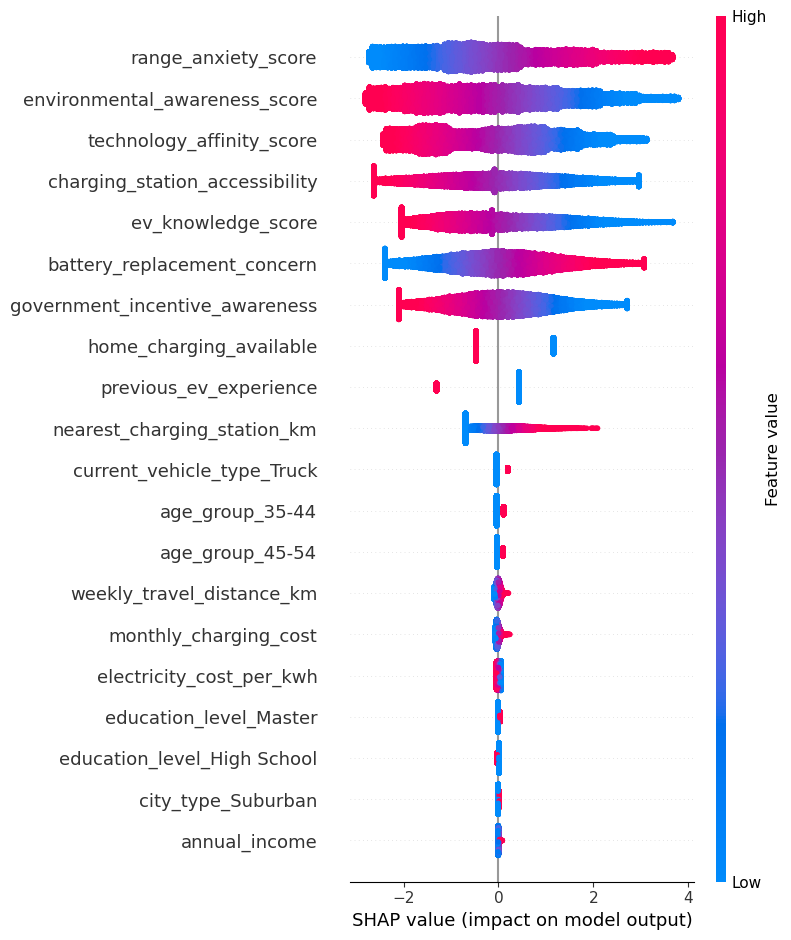

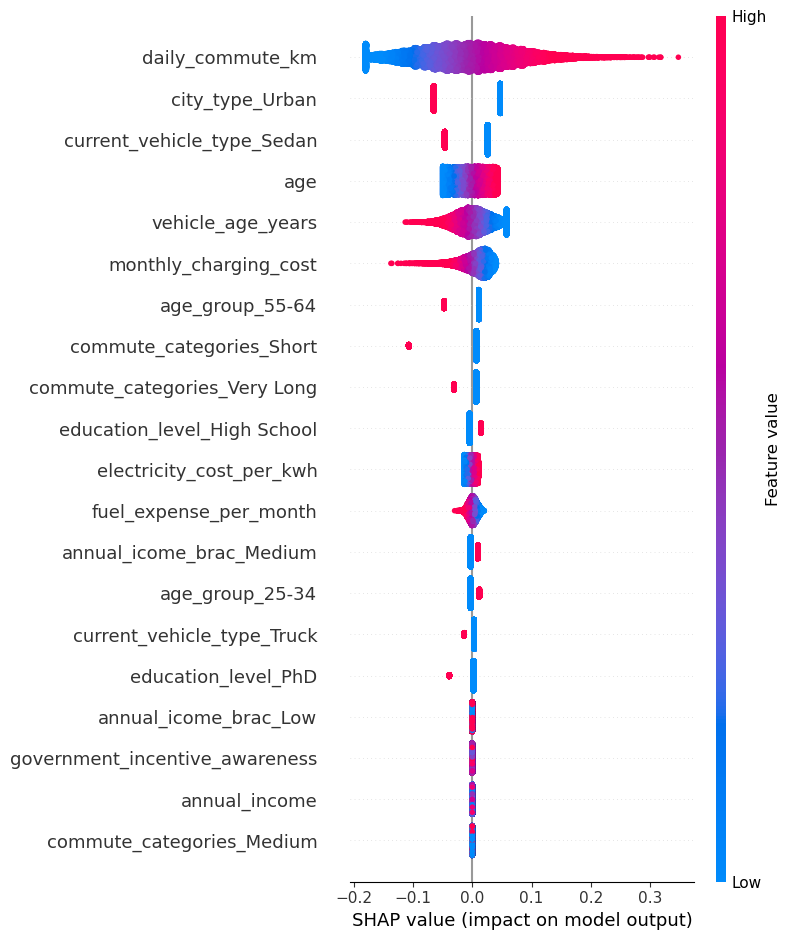

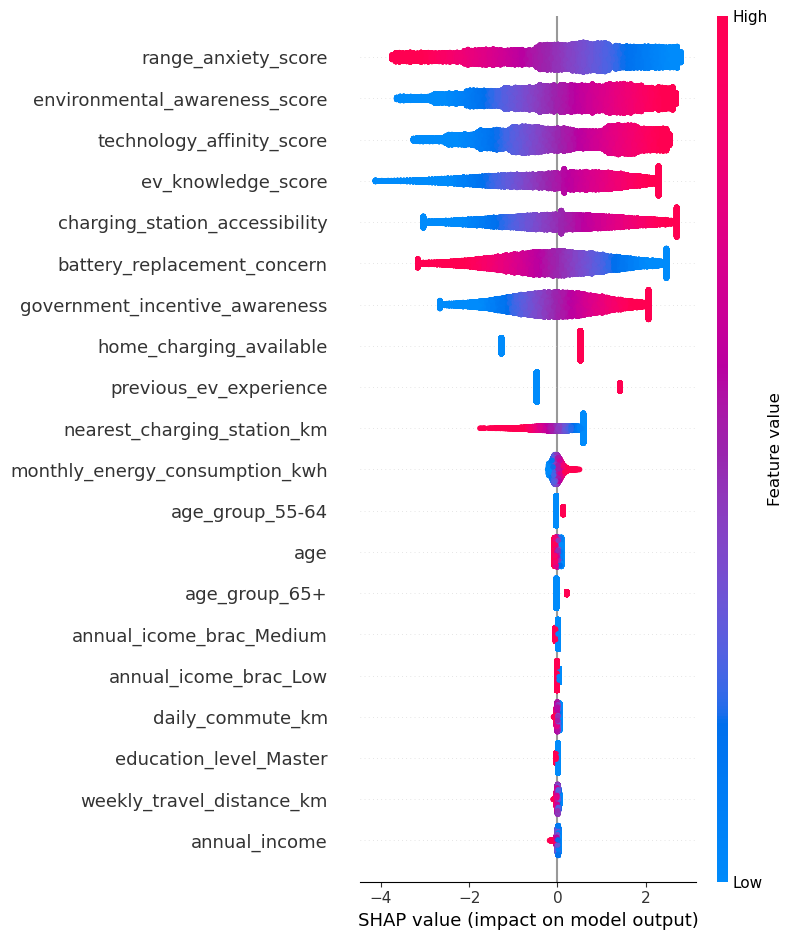

In [74]:
explainer = shap.LinearExplainer(best_model.named_steps['classifier'], best_model.named_steps["pipe"].transform(X_train))
shap_values = explainer(best_model.named_steps["pipe"].transform(X_train))
feature_name = best_model.named_steps["pipe"].get_feature_names_out()

#Class Low (0)
shap.summary_plot(
    shap_values.values[:, :, 0],
    best_model.named_steps["pipe"].transform(X_train),
    feature_names=feature_name)

#Class Medium (1)
shap.summary_plot(
    shap_values.values[:, :, 1],
    best_model.named_steps["pipe"].transform(X_train),
    feature_names=feature_name)

#class High(2)
shap.summary_plot(
    shap_values.values[:, :, 2],
    best_model.named_steps["pipe"].transform(X_train),
    feature_names=feature_name)

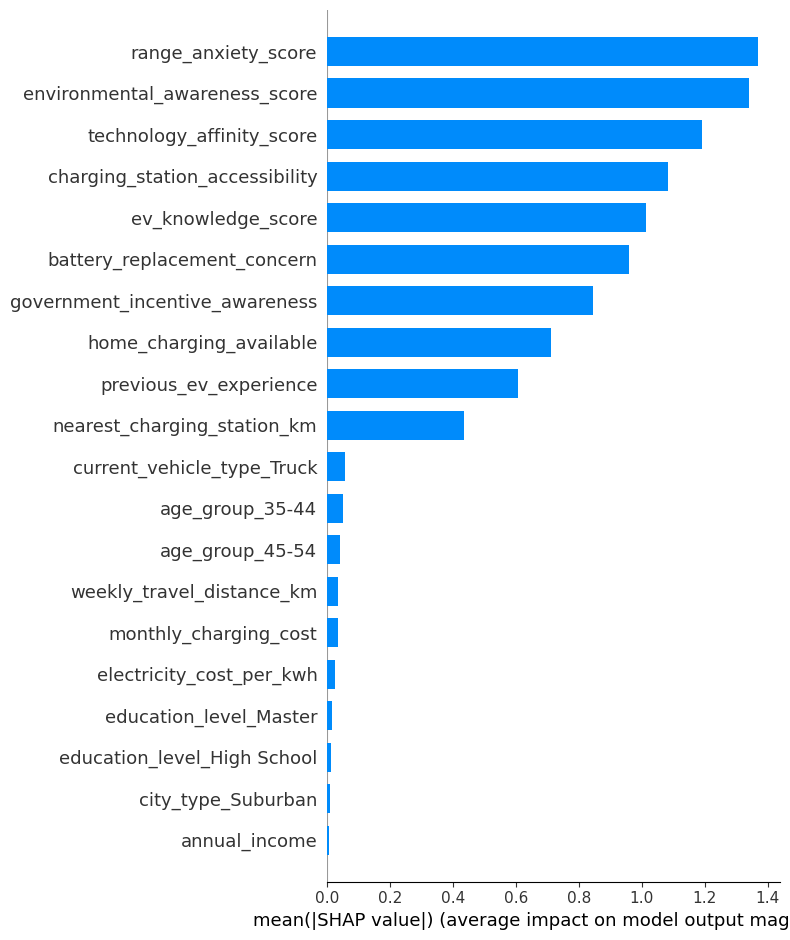

Class 0 Done✅


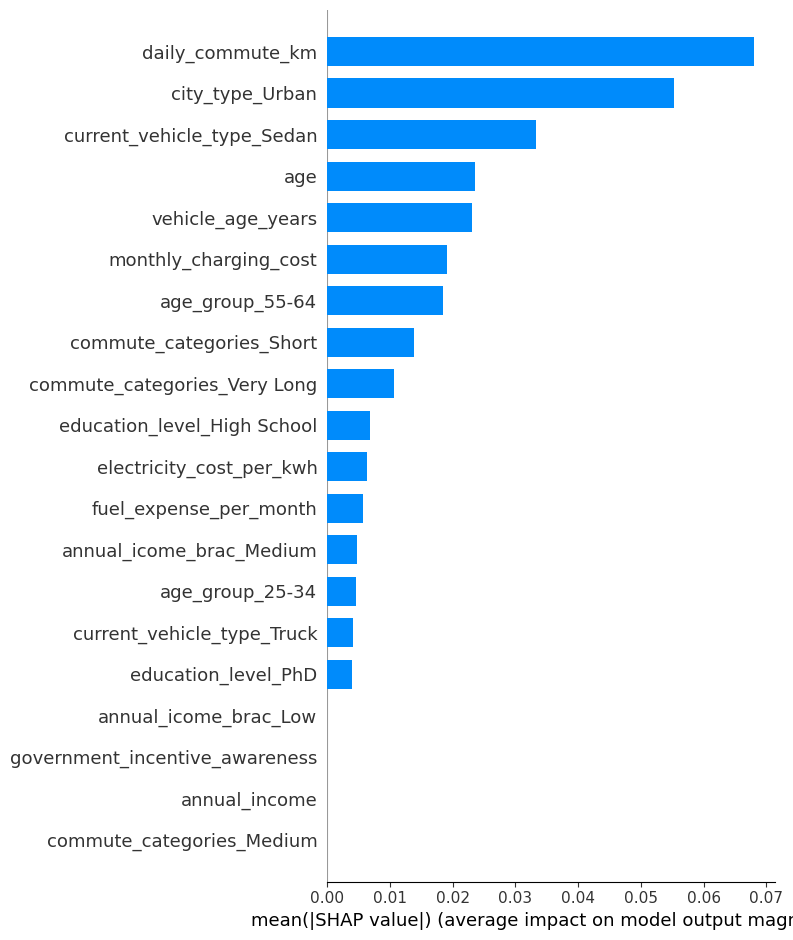

Class 1 Done✅


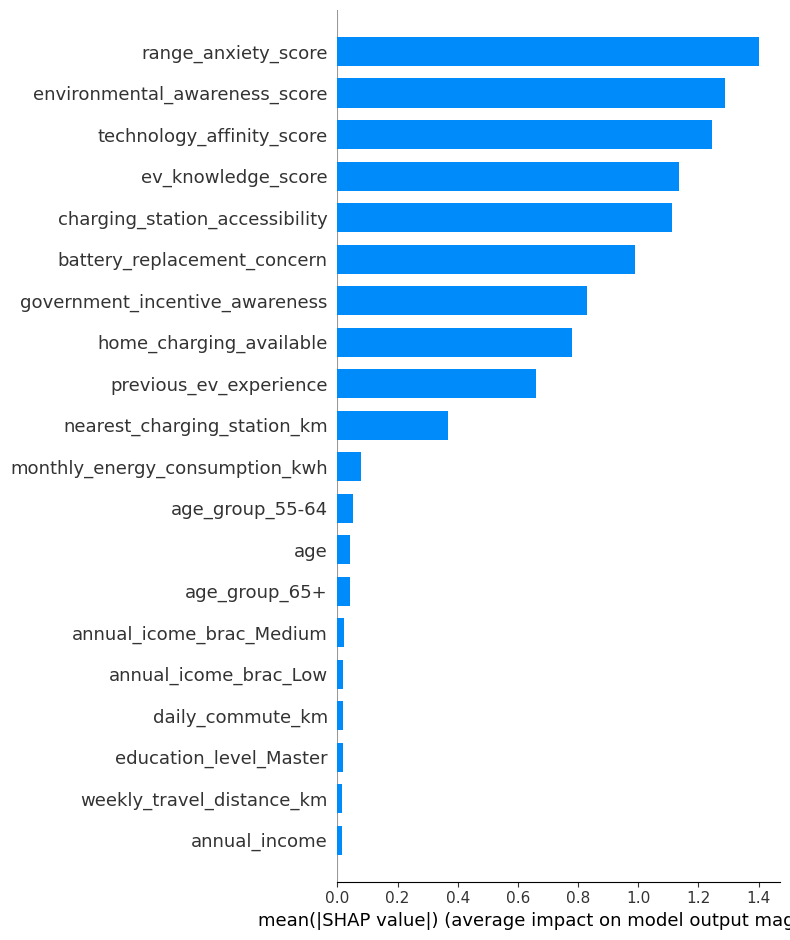

Class 2 Done✅


In [75]:
#Class 0 (low)
shap.summary_plot(
    shap_values.values[:, :, 0],
    best_model.named_steps["pipe"].transform(X_train),
    feature_names=feature_name,
    plot_type='bar')
print(f"Class 0 Done✅")
#Class 1 (medium)
shap.summary_plot(
    shap_values.values[:, :, 1],
    best_model.named_steps["pipe"].transform(X_train),
    feature_names=feature_name,
    plot_type='bar')
print(f"Class 1 Done✅")
#Class 2 (High)
shap.summary_plot(
    shap_values.values[:, :, 2],
    best_model.named_steps["pipe"].transform(X_train),
    feature_names=feature_name,
    plot_type='bar')
print(f"Class 2 Done✅")

In [76]:
importance = np.abs(shap_values.values).mean(axis=(0, 2))

importance_df = (
    pd.DataFrame({
        "Feature": feature_name,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)
importance_df.head(15)

,Feature,Importance
13,range_anxiety_score,0.924003
10,environmental_awareness_score,0.877061
12,technology_affinity_score,0.811460
6,charging_station_accessibility,0.731590
15,ev_knowledge_score,0.716723
14,battery_replacement_concern,0.649634
11,government_incentive_awareness,0.558035
8,home_charging_available,0.497757
16,previous_ev_experience,0.421850
7,nearest_charging_station_km,0.267296


In [77]:
import joblib

In [78]:
joblib.dump(best_model,
           "ev_adoption_model.pkl")

['ev_adoption_model.pkl']

In [79]:
joblib.dump(pipeline,
           "scaler_encode.pkl")

['scaler_encode.pkl']

In [80]:
import pandas as pd

new_data = pd.DataFrame({
    "age":[35],
    "monthly_charging_cost": [75.0],
    "monthly_income":[350000],
    "travel_distance":[18],
    "charging_availability":[1],
    "environmental_concern":[8],
    "ev_knowledge_score":[7],
    "previous_ev_experience": [1],
    "city_type": ['Rural'],
    'home_charging_available':[1], 
    'electricity_cost_per_kwh':[0.15],
    'age_group': ['55-64'],
    'annual_icome_brac': ['High'],
    'weekly_travel_distance_km': [300.5],
    'charging_station_accessibility': [4.0],
    'annual_income': [4_200_000],
    'education_level': ['PhD'],
    'government_incentive_awareness': [7.5],
    'vehicle_age_years': [7.5],
    'battery_replacement_concern': [10.5],
    'technology_affinity_score': [7.5], 
    'daily_commute_km': [45.6],
    'monthly_energy_consumption_kwh': [1000], 
    'commute_categories':['Long'],
    'nearest_charging_station_km': [55],
    'fuel_expense_per_month': [500],
    'environmental_awareness_score': [9.5],
    'range_anxiety_score': [5.5],
    'current_vehicle_type': ['Sedan']
    
})

In [81]:
prob = best_model.predict_proba(new_data)
prediction = best_model.predict(new_data)
print(f"Electric Vehicle Adoption Likelyhood probability: {prob}")
print(f"Electric Vehicle Adoption Likelyhood Predicted: {prediction}")

Electric Vehicle Adoption Likelyhood probability: [[0.41660713 0.57772835 0.00566453]]
Electric Vehicle Adoption Likelyhood Predicted: [1]
